In [1]:
import pandas as pd

path = "../luad_tcga_pan_can_atlas_2018/"

# ----------------------
# LOAD EXPRESSION DATA
# ----------------------
expr = pd.read_csv(path + "data_mrna_seq_v2_rsem.txt", sep="\t")
expr = expr.drop([0])  # remove metadata row

# Rename gene column
expr = expr.rename(columns={"Hugo_Symbol": "Gene"})

print("Expression loaded:", expr.shape)



Expression loaded: (20530, 512)


In [2]:
expr.head()

,Gene,Entrez_Gene_Id,TCGA-05-4244-01,TCGA-05-4249-01,TCGA-05-4250-01,TCGA-05-4382-01,TCGA-05-4384-01,TCGA-05-4389-01,TCGA-05-4390-01,TCGA-05-4395-01,...,TCGA-NJ-A4YG-01,TCGA-NJ-A4YI-01,TCGA-NJ-A4YP-01,TCGA-NJ-A4YQ-01,TCGA-NJ-A55A-01,TCGA-NJ-A55O-01,TCGA-NJ-A55R-01,TCGA-NJ-A7XG-01,TCGA-O1-A52J-01,TCGA-S2-AA1A-01
1,NaN,100133144,10.0113,7.1957,7.2453,11.3311,3.2254,4.0000,7.1084,3.4360,...,11.7148,3.6657,2.3298,16.3214,20.3514,15.5193,8.4195,42.9857,14.0861,20.5338
2,UBE2Q2P2,100134869,11.2820,12.4436,6.0184,7.5740,3.4942,13.7852,7.5810,12.1335,...,11.9573,9.7617,8.3410,7.5330,17.2393,22.9872,10.3226,81.1128,24.1914,8.9500
3,HMGB1P1,10357,49.5994,90.5117,49.5366,82.8303,72.5351,66.3658,109.1810,57.0596,...,163.5740,130.7490,101.7400,82.4231,100.4200,100.1870,74.7210,85.3715,61.1388,76.9265
4,NaN,10431,848.9400,924.0160,1140.6800,807.1730,562.0040,1342.6200,1148.3300,955.9140,...,919.1690,403.4910,918.9530,995.6060,536.7600,873.9790,766.7450,677.7330,1137.3200,565.4330
5,NaN,136542,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [3]:
# 🔥 Remove rows where gene name is missing

expr = expr.dropna(subset=["Gene"])

In [4]:
expr.head()

,Gene,Entrez_Gene_Id,TCGA-05-4244-01,TCGA-05-4249-01,TCGA-05-4250-01,TCGA-05-4382-01,TCGA-05-4384-01,TCGA-05-4389-01,TCGA-05-4390-01,TCGA-05-4395-01,...,TCGA-NJ-A4YG-01,TCGA-NJ-A4YI-01,TCGA-NJ-A4YP-01,TCGA-NJ-A4YQ-01,TCGA-NJ-A55A-01,TCGA-NJ-A55O-01,TCGA-NJ-A55R-01,TCGA-NJ-A7XG-01,TCGA-O1-A52J-01,TCGA-S2-AA1A-01
2,UBE2Q2P2,100134869,11.2820,12.4436,6.0184,7.5740,3.4942,13.7852,7.5810,12.1335,...,11.9573,9.7617,8.3410,7.5330,17.2393,22.9872,10.3226,81.1128,24.1914,8.9500
3,HMGB1P1,10357,49.5994,90.5117,49.5366,82.8303,72.5351,66.3658,109.1810,57.0596,...,163.5740,130.7490,101.7400,82.4231,100.4200,100.1870,74.7210,85.3715,61.1388,76.9265
7,RNU12-2P,26823,1.0472,1.6098,0.0000,0.4786,0.6109,0.3356,1.2773,0.5369,...,0.0000,0.0000,0.0000,0.6277,0.8742,1.1669,0.7209,0.0000,2.8708,0.6552
8,SSX9P,280660,0.0000,0.0000,0.0000,0.2393,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,1.8832,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
10,EZHIP,340602,0.0000,0.0000,0.0000,7.6577,0.0000,0.0000,0.0000,0.0000,...,0.5774,1.3427,1.0163,0.0000,2.6226,0.0000,1.9223,0.0000,3.3493,2.6208


In [5]:
expr.shape

(20518, 512)

In [6]:
# 🔥 Remove duplicate genes (important)

expr = expr.drop_duplicates(subset=["Gene"])

In [7]:
expr.shape

(20511, 512)

In [8]:
# 🔥 Drop Entrez ID (not needed)

expr = expr.drop(columns=["Entrez_Gene_Id"], errors="ignore")

In [9]:
print("Clean Expression shape:", expr.shape)

expr.head()

Clean Expression shape: (20511, 511)


,Gene,TCGA-05-4244-01,TCGA-05-4249-01,TCGA-05-4250-01,TCGA-05-4382-01,TCGA-05-4384-01,TCGA-05-4389-01,TCGA-05-4390-01,TCGA-05-4395-01,TCGA-05-4396-01,...,TCGA-NJ-A4YG-01,TCGA-NJ-A4YI-01,TCGA-NJ-A4YP-01,TCGA-NJ-A4YQ-01,TCGA-NJ-A55A-01,TCGA-NJ-A55O-01,TCGA-NJ-A55R-01,TCGA-NJ-A7XG-01,TCGA-O1-A52J-01,TCGA-S2-AA1A-01
2,UBE2Q2P2,11.2820,12.4436,6.0184,7.5740,3.4942,13.7852,7.5810,12.1335,16.0273,...,11.9573,9.7617,8.3410,7.5330,17.2393,22.9872,10.3226,81.1128,24.1914,8.9500
3,HMGB1P1,49.5994,90.5117,49.5366,82.8303,72.5351,66.3658,109.1810,57.0596,108.4150,...,163.5740,130.7490,101.7400,82.4231,100.4200,100.1870,74.7210,85.3715,61.1388,76.9265
7,RNU12-2P,1.0472,1.6098,0.0000,0.4786,0.6109,0.3356,1.2773,0.5369,0.7582,...,0.0000,0.0000,0.0000,0.6277,0.8742,1.1669,0.7209,0.0000,2.8708,0.6552
8,SSX9P,0.0000,0.0000,0.0000,0.2393,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,1.8832,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
10,EZHIP,0.0000,0.0000,0.0000,7.6577,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.5774,1.3427,1.0163,0.0000,2.6226,0.0000,1.9223,0.0000,3.3493,2.6208


In [10]:
# ----------------------
# TRANSPOSE EXPRESSION
# ----------------------
expr_t = expr.set_index("Gene").T
expr_t.index.name = "Patient_ID"
expr_t.reset_index(inplace=True)

print("Expression transposed:", expr_t.shape)

Expression transposed: (510, 20512)


In [11]:
# Convert sample ID → patient ID

expr_t["Patient_ID"] = expr_t["Patient_ID"].apply(lambda x: x[:12])

In [12]:
expr_t.head()

Gene,Patient_ID,UBE2Q2P2,HMGB1P1,RNU12-2P,SSX9P,EZHIP,EFCAB8,SRP14P1,TRIM75P,SPATA31B1P,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
0,TCGA-05-4244,11.2820,49.5994,1.0472,0.0000,0.0000,5.2361,5.5851,0.0000,0.0,...,221.164,517.672,39.7940,292.521,959.246,0.6981,1088.050,2837.94,871.28,575.268
1,TCGA-05-4249,12.4436,90.5117,1.6098,0.0000,0.0000,1.2878,5.1513,0.0000,0.0,...,198.589,287.507,62.1376,493.560,1179.330,20.2833,787.506,2351.25,1138.12,690.275
2,TCGA-05-4250,6.0184,49.5366,0.0000,0.0000,0.0000,0.0000,4.9739,0.0000,0.0,...,520.899,1046.840,60.0182,365.415,843.903,26.5274,475.172,5437.45,1170.52,532.869
3,TCGA-05-4382,7.5740,82.8303,0.4786,0.2393,7.6577,1.4358,4.3075,0.2393,0.0,...,429.630,753.090,40.4424,346.752,946.687,64.8514,908.159,6770.15,1169.24,663.830
4,TCGA-05-4384,3.4942,72.5351,0.6109,0.0000,0.0000,1.2217,6.1087,0.0000,0.0,...,258.302,153.940,80.0244,563.225,1320.710,7.9414,778.864,3341.48,1737.32,723.274


In [13]:
print(expr_t.columns.tolist())

['Patient_ID', 'UBE2Q2P2', 'HMGB1P1', 'RNU12-2P', 'SSX9P', 'EZHIP', 'EFCAB8', 'SRP14P1', 'TRIM75P', 'SPATA31B1P', 'REXO1L6P', 'SDR16C6P', 'HSPB1P1', 'PPBPP1', 'ANKRD20A20P', 'GTPBP6', 'EFCAB12', 'A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS', 'AACS', 'AACSL', 'AADAC', 'AADACL2', 'AADACL3', 'AADACL4', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS', 'AARS2', 'AARSD1', 'AASDH', 'AASDHPPT', 'AASS', 'AATF', 'AATK', 'ABAT', 'ABCA10', 'ABCA1', 'ABCA11P', 'ABCA12', 'ABCA13', 'ABCA17P', 'ABCA2', 'ABCA3', 'ABCA4', 'ABCA5', 'ABCA6', 'ABCA7', 'ABCA8', 'ABCA9', 'ABCB10', 'ABCB11', 'ABCB1', 'ABCB4', 'ABCB5', 'ABCB6', 'ABCB7', 'ABCB8', 'ABCB9', 'ABCC10', 'ABCC11', 'ABCC12', 'ABCC13', 'ABCC1', 'ABCC2', 'ABCC3', 'ABCC4', 'ABCC5', 'ABCC6', 'ABCC6P1', 'ABCC6P2', 'ABCC8', 'ABCC9', 'ABCD1', 'ABCD2', 'ABCD3', 'ABCD4', 'ABCE1', 'ABCF1', 'ABCF2', 'ABCF3', 'ABCG1', 'ABCG2', 'ABCG4', 'ABCG5', 'ABCG8', 'ABHD10', 'ABHD11', 'ABHD12', 'ABHD12B', 'ABHD13', 'ABHD14A', 'ABHD14B'

In [14]:
expr_t.isnull().sum()

Gene
Patient_ID    0
UBE2Q2P2      0
HMGB1P1       0
RNU12-2P      0
SSX9P         0
             ..
ZYG11A        0
ZYG11B        0
ZYX           0
ZZEF1         0
ZZZ3          0
Length: 20512, dtype: int64

In [15]:
#save the expr_t dataframe to a csv file
expr_t.to_csv("../Data/processed_data/selected_expression.csv", index=False)

# Model Building — Gene Expression → OS_STATUS, PFS_STATUS, Stage
# v2: Correct train/test split — feature selection and CV on train only, evaluate on held-out test

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_selection import f_classif, VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score

## Step 1 — Log Transform + Variance Filter

RSEM values are right-skewed. log1p stabilises variance before any modelling.  
Then drop the bottom 50% lowest-variance genes — they carry almost no signal.

In [17]:
# Log transform (log1p handles zeros safely)
expr_log = expr_t.set_index('Patient_ID').apply(np.log1p)

# Variance filter: keep top 50% most variable genes
gene_var = expr_log.var(axis=0)
keep_genes = gene_var[gene_var >= gene_var.median()].index
expr_filtered = expr_log[keep_genes]

print(f"After log + variance filter: {expr_filtered.shape}")
print(f"Removed {expr_log.shape[1] - expr_filtered.shape[1]:,} low-variance genes")

After log + variance filter: (510, 10256)
Removed 10,255 low-variance genes


## Step 2 — Merge with Clinical Data

In [18]:
clinical = pd.read_csv('../Data/processed_data/mutation_data_processed/selected_clinical.csv',
                       index_col='PATIENT_ID')

print("Clinical shape:", clinical.shape)
print("Columns:", clinical.columns.tolist())
print("\nStage value counts:")
print(clinical['AJCC_PATHOLOGIC_TUMOR_STAGE'].value_counts().sort_index())

Clinical shape: (463, 10)
Columns: ['AJCC_PATHOLOGIC_TUMOR_STAGE', 'HISTORY_NEOADJUVANT_TRTYN', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PRIOR_DX', 'RADIATION_THERAPY', 'OS_STATUS', 'PFS_STATUS']

Stage value counts:
AJCC_PATHOLOGIC_TUMOR_STAGE
1.0      5
1.1    127
1.2    120
2.0      1
2.1     49
2.2     67
3.1     61
3.2      9
4.0     24
Name: count, dtype: int64


In [19]:
# OS_STATUS and PFS_STATUS are already 0/1 integers in selected_clinical.csv
# AJCC_PATHOLOGIC_TUMOR_STAGE is already numeric: 1.0, 1.1, 1.2, 2.0, 2.1, 2.2, 3.1, 3.2, 4.0
# Encode as integer major stage: 1, 2, 3, 4
clinical['Stage'] = clinical['AJCC_PATHOLOGIC_TUMOR_STAGE'].apply(lambda x: int(x) if pd.notna(x) else np.nan)

ml = expr_filtered.join(clinical, how='inner').dropna(
    subset=['OS_STATUS', 'PFS_STATUS', 'Stage'])

ml['OS_STATUS']  = ml['OS_STATUS'].astype(int)
ml['PFS_STATUS'] = ml['PFS_STATUS'].astype(int)
ml['Stage']      = ml['Stage'].astype(int)

print("Merged shape:", ml.shape)
print("\nOS_STATUS:  ", ml['OS_STATUS'].value_counts().to_dict())
print("PFS_STATUS: ", ml['PFS_STATUS'].value_counts().to_dict())
print("Stage:      ", ml['Stage'].value_counts().sort_index().to_dict())

Merged shape: (459, 10267)

OS_STATUS:   {0: 290, 1: 169}
PFS_STATUS:  {0: 259, 1: 200}
Stage:       {1: 249, 2: 116, 3: 70, 4: 24}


## Step 3 — Train/Test Split + Feature Selection Helper

**80% train / 20% test** — all feature selection and CV happen on train only.  
Test set is locked away and used only for the final honest AUC evaluation.

In [20]:
clinical_cols = list(clinical.columns) + ['Stage']
gene_cols     = [c for c in ml.columns if c not in clinical_cols]

# 80/20 stratified split — same split for all three targets
train_idx, test_idx = train_test_split(
    ml.index, test_size=0.2, stratify=ml['OS_STATUS'], random_state=42
)

ml_train = ml.loc[train_idx]
ml_test  = ml.loc[test_idx]

X_all   = ml[gene_cols]         # full data — used only for final retrain
X_train = ml_train[gene_cols]   # feature selection + CV use this
X_test  = ml_test[gene_cols]    # honest evaluation uses this

print(f"Train: {len(ml_train)} patients  |  Test: {len(ml_test)} patients")
print(f"\nOS    train={ml_train['OS_STATUS'].value_counts().to_dict()}   test={ml_test['OS_STATUS'].value_counts().to_dict()}")
print(f"PFS   train={ml_train['PFS_STATUS'].value_counts().to_dict()}  test={ml_test['PFS_STATUS'].value_counts().to_dict()}")
print(f"Stage train={ml_train['Stage'].value_counts().sort_index().to_dict()}  test={ml_test['Stage'].value_counts().sort_index().to_dict()}")


def select_features(X, y, rf_top=50, lasso_C=0.05, p_thresh=0.05):
    f_scores, p_values = f_classif(X, y)
    anova_genes = set(X.columns[p_values < p_thresh])

    rf = RandomForestClassifier(n_estimators=300, random_state=42,
                                class_weight='balanced', n_jobs=-1)
    rf.fit(X, y)
    rf_imp = pd.Series(rf.feature_importances_, index=X.columns)
    rf_genes = set(rf_imp.nlargest(rf_top).index)

    lasso = LogisticRegression(solver='saga', l1_ratio=1, C=lasso_C,
                               random_state=42, class_weight='balanced', max_iter=5000)
    lasso.fit(X, y)
    nonzero_mask = (lasso.coef_ != 0).any(axis=0)
    lasso_genes  = set(X.columns[nonzero_mask])

    votes = Counter(list(anova_genes) + list(rf_genes) + list(lasso_genes))
    consensus = [g for g, v in votes.items() if v >= 2]

    print(f"  ANOVA: {len(anova_genes)}  |  RF top {rf_top}: {len(rf_genes)}  |  LASSO: {len(lasso_genes)}  →  Consensus: {len(consensus)}")
    return consensus

print("\nSplit and helpers defined.")

Train: 367 patients  |  Test: 92 patients

OS    train={0: 232, 1: 135}   test={0: 58, 1: 34}
PFS   train={0: 207, 1: 160}  test={0: 52, 1: 40}
Stage train={1: 195, 2: 92, 3: 60, 4: 20}  test={1: 54, 2: 24, 3: 10, 4: 4}

Split and helpers defined.


In [21]:
def train_and_eval(X_train, y_train, X_test, y_test, label, scoring='roc_auc'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    models = {
        'Random Forest':    RandomForestClassifier(n_estimators=300, random_state=42,
                                                   class_weight='balanced', n_jobs=-1),
        'Logistic (LASSO)': LogisticRegression(solver='saga', l1_ratio=1, C=0.1,
                                                random_state=42, class_weight='balanced',
                                                max_iter=5000),
    }
    print(f"\n--- {label} ---")
    print(f"  {'Model':<25} {'CV AUC (train)':>16}   {'Test AUC':>8}")
    res = {}
    for name, model in models.items():
        # CV on train set only
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=scoring)

        # Fit on full train set, evaluate on locked-away test set
        model.fit(X_train, y_train)
        if scoring == 'roc_auc_ovr_weighted':
            y_prob   = model.predict_proba(X_test)
            test_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        else:
            y_prob   = model.predict_proba(X_test)[:, 1]
            test_auc = roc_auc_score(y_test, y_prob)

        res[name] = {'cv_scores': cv_scores, 'test_auc': test_auc, 'model': model}
        print(f"  {name:<25} {cv_scores.mean():.3f} ± {cv_scores.std():.3f}      {test_auc:.3f}")
    return res

print("Training helper defined.")

Training helper defined.


## Step 4 — OS_STATUS Prediction

In [22]:
y_os_train = ml_train['OS_STATUS']
y_os_test  = ml_test['OS_STATUS']

print("Selecting features for OS_STATUS (train set only)...")
os_genes = select_features(X_train, y_os_train)

os_results = train_and_eval(X_train[os_genes], y_os_train,
                             X_test[os_genes],  y_os_test,
                             "OS_STATUS — gene expression")

Selecting features for OS_STATUS (train set only)...
  ANOVA: 2003  |  RF top 50: 50  |  LASSO: 76  →  Consensus: 88

--- OS_STATUS — gene expression ---
  Model                       CV AUC (train)   Test AUC
  Random Forest             0.722 ± 0.036      0.630
  Logistic (LASSO)          0.712 ± 0.069      0.606


## Step 5 — PFS_STATUS Prediction

In [23]:
y_pfs_train = ml_train['PFS_STATUS']
y_pfs_test  = ml_test['PFS_STATUS']

print("Selecting features for PFS_STATUS (train set only)...")
pfs_genes = select_features(X_train, y_pfs_train)

pfs_results = train_and_eval(X_train[pfs_genes], y_pfs_train,
                              X_test[pfs_genes],  y_pfs_test,
                              "PFS_STATUS — gene expression")

Selecting features for PFS_STATUS (train set only)...
  ANOVA: 1168  |  RF top 50: 50  |  LASSO: 79  →  Consensus: 71

--- PFS_STATUS — gene expression ---
  Model                       CV AUC (train)   Test AUC
  Random Forest             0.693 ± 0.045      0.577
  Logistic (LASSO)          0.690 ± 0.027      0.504


## Step 6 — Stage Prediction 

In [24]:
y_stage_train = ml_train['Stage']
y_stage_test  = ml_test['Stage']

print("Stage distribution (train):", y_stage_train.value_counts().sort_index().to_dict())
print("\nSelecting features for Stage (train set only)...")
stage_genes = select_features(X_train, y_stage_train)

stage_results = train_and_eval(X_train[stage_genes], y_stage_train,
                                X_test[stage_genes],  y_stage_test,
                                "Stage (I/II/III/IV) — gene expression",
                                scoring='roc_auc_ovr_weighted')

Stage distribution (train): {1: 195, 2: 92, 3: 60, 4: 20}

Selecting features for Stage (train set only)...
  ANOVA: 1484  |  RF top 50: 50  |  LASSO: 174  →  Consensus: 99

--- Stage (I/II/III/IV) — gene expression ---
  Model                       CV AUC (train)   Test AUC
  Random Forest             0.716 ± 0.035      0.557
  Logistic (LASSO)          0.738 ± 0.050      0.551


## Step 7 — Summary Plot + Save Selected Genes

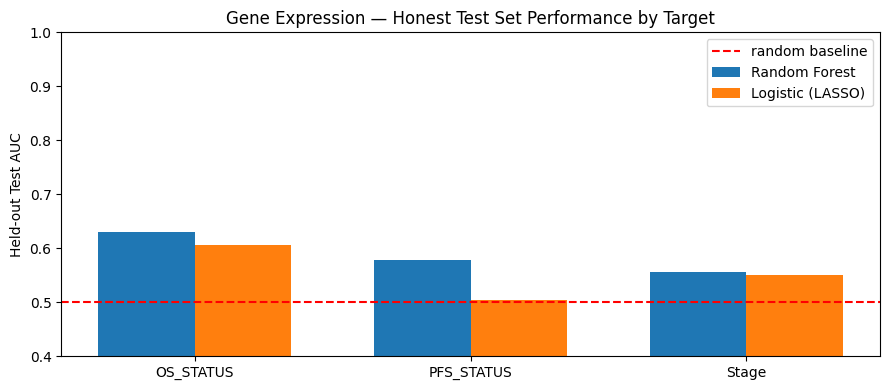

In [25]:
# Summary: test AUC per target per model
all_results = {
    'OS_STATUS':  os_results,
    'PFS_STATUS': pfs_results,
    'Stage':      stage_results,
}
model_names = list(os_results.keys())

fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(len(all_results))
width = 0.35

for i, mname in enumerate(model_names):
    test_aucs = [all_results[t][mname]['test_auc'] for t in all_results]
    ax.bar(x + i*width, test_aucs, width, label=mname)

ax.axhline(0.5, color='red', linestyle='--', label='random baseline')
ax.set_xticks(x + width/2)
ax.set_xticklabels(list(all_results.keys()))
ax.set_ylabel('Held-out Test AUC')
ax.set_title('Gene Expression — Honest Test Set Performance by Target')
ax.legend()
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

In [67]:
all_selected = list(set(os_genes + pfs_genes + stage_genes))

save_cols = all_selected + ['OS_STATUS', 'PFS_STATUS', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'Stage']
ml_save = ml[[c for c in save_cols if c in ml.columns]]
#ml_save.to_csv('../Data/processed_data/expression_ml_ready.csv')

#print(f"Saved {ml_save.shape[0]} patients × {len(all_selected)} selected genes + targets")
print(f"\nGenes per target:  OS={len(os_genes)}  PFS={len(pfs_genes)}  Stage={len(stage_genes)}")
print(f"Union (all targets): {len(all_selected)} genes")


Genes per target:  OS=112  PFS=86  Stage=132
Union (all targets): 305 genes


## Step 8 — Model Selection

Pick the best model per target based on CV AUC mean. Prefer lower std (stability) when means are tied.

In [26]:
task_registry = {
    'OS_STATUS':  {'results': os_results,    'genes': os_genes,    'scoring': 'roc_auc'},
    'PFS_STATUS': {'results': pfs_results,   'genes': pfs_genes,   'scoring': 'roc_auc'},
    'Stage':      {'results': stage_results, 'genes': stage_genes, 'scoring': 'roc_auc_ovr_weighted'},
}

print(f"{'Target':<14} {'Model':<25} {'CV AUC (train)':>16} {'Test AUC':>10}  Decision")
print("-" * 85)

selected_models = {}
for target, info in task_registry.items():
    res = info['results']
    # Select by highest held-out test AUC (the honest score)
    best_name = max(res, key=lambda k: res[k]['test_auc'])
    selected_models[target] = best_name

    for name, scores in res.items():
        cv_mean = scores['cv_scores'].mean()
        cv_std  = scores['cv_scores'].std()
        t_auc   = scores['test_auc']
        marker  = " ← SELECTED" if name == best_name else ""
        print(f"{target:<14} {name:<25} {cv_mean:.3f} ± {cv_std:.3f}   {t_auc:>8.3f}{marker}")

Target         Model                       CV AUC (train)   Test AUC  Decision
-------------------------------------------------------------------------------------
OS_STATUS      Random Forest             0.722 ± 0.036      0.630 ← SELECTED
OS_STATUS      Logistic (LASSO)          0.712 ± 0.069      0.606
PFS_STATUS     Random Forest             0.693 ± 0.045      0.577 ← SELECTED
PFS_STATUS     Logistic (LASSO)          0.690 ± 0.027      0.504
Stage          Random Forest             0.716 ± 0.035      0.557 ← SELECTED
Stage          Logistic (LASSO)          0.738 ± 0.050      0.551


## Step 9 — Retrain Best Models on Full Data + Save to Feature Store

Feature store layout:
```
Data/feature_store/
  expression/
    OS_STATUS/
      features.csv      ← patient × gene matrix (selected genes only)
      gene_list.txt     ← one gene per line
      model.joblib      ← fitted sklearn model
      metadata.json     ← AUC, gene count, model type, date
    PFS_STATUS/  ...
    Stage/       ...
  registry.json         ← index of all stored models
```

In [27]:
import joblib, json, os
from datetime import date

FEATURE_STORE_ROOT = '../Data/feature_store/expression'

model_blueprints = {
    'Random Forest':    lambda: RandomForestClassifier(n_estimators=300, random_state=42,
                                                       class_weight='balanced', n_jobs=-1),
    'Logistic (LASSO)': lambda: LogisticRegression(solver='saga', l1_ratio=1, C=0.1,
                                                    random_state=42, class_weight='balanced',
                                                    max_iter=5000),
}

registry = {}

for target, info in task_registry.items():
    genes      = info['genes']
    scoring    = info['scoring']
    model_name = selected_models[target]
    res        = info['results'][model_name]

    # Retrain best model on ALL data (train + test) for deployment
    final_model = model_blueprints[model_name]()
    final_model.fit(X_all[genes], ml[target])

    store_dir = os.path.join(FEATURE_STORE_ROOT, target)
    os.makedirs(store_dir, exist_ok=True)

    X_all[genes].to_csv(os.path.join(store_dir, 'features.csv'))

    with open(os.path.join(store_dir, 'gene_list.txt'), 'w') as f:
        f.write('\n'.join(genes))

    joblib.dump(final_model, os.path.join(store_dir, 'model.joblib'))

    meta = {
        'target':        target,
        'model_type':    model_name,
        'n_genes':       len(genes),
        'cv_auc_mean':   round(res['cv_scores'].mean(), 4),
        'cv_auc_std':    round(res['cv_scores'].std(),  4),
        'test_auc':      round(res['test_auc'], 4),   # honest score — use this
        'scoring':       scoring,
        'train_patients': len(ml_train),
        'test_patients':  len(ml_test),
        'total_patients': len(ml),
        'created':        str(date.today()),
    }
    with open(os.path.join(store_dir, 'metadata.json'), 'w') as f:
        json.dump(meta, f, indent=2)

    registry[target] = meta
    print(f"✓ {target:<14} | {model_name:<25} | CV {meta['cv_auc_mean']:.3f} | Test {meta['test_auc']:.3f} | {len(genes)} genes")

with open(os.path.join(FEATURE_STORE_ROOT, '../registry.json'), 'w') as f:
    json.dump(registry, f, indent=2)

print(f"\nFeature store saved → {FEATURE_STORE_ROOT}")

✓ OS_STATUS      | Random Forest             | CV 0.722 | Test 0.630 | 88 genes
✓ PFS_STATUS     | Random Forest             | CV 0.693 | Test 0.577 | 71 genes
✓ Stage          | Random Forest             | CV 0.716 | Test 0.557 | 99 genes

Feature store saved → ../Data/feature_store/expression


## How to reload from the Feature Store in another notebook

```python
import joblib, json, pandas as pd

target = 'OS_STATUS'   # or 'PFS_STATUS', 'Stage'
store_dir = f'../Data/feature_store/expression/{target}'

# Load features
features = pd.read_csv(f'{store_dir}/features.csv', index_col=0)

# Load model
model = joblib.load(f'{store_dir}/model.joblib')

# Load metadata
with open(f'{store_dir}/metadata.json') as f:
    meta = json.load(f)

print(meta)
predictions = model.predict(features)
```

In [ ]:


# import seaborn as sns
# import matplotlib.pyplot as plt

# corr = X_train[os_genes].corr()

# plt.figure(figsize=(12, 10))
# sns.heatmap(corr, cmap="coolwarm", center=0)
# plt.title("Correlation Heatmap — OS Selected Genes")
# plt.show()